# Preprocessing: convert columns to format expected by Pisces

In [19]:
import pandas as pd

day_fn = '/Users/eric/Engineering/Work/pisces/data/eric_exports/raw_accelerometer/2024_12_11_wake.csv'
night_fn = '/Users/eric/Engineering/Work/pisces/data/eric_exports/raw_accelerometer/2024_12_1011.csv'

day = pd.read_csv(day_fn)
night = pd.read_csv(night_fn)

/var/folders/h4/pg7xmblx74zbp2yhls4bc_mh0000gn/T/ipykernel_91386/2595619436.py:6: DtypeWarning: Columns (40,42,43,51) have mixed types. Specify dtype option on import or set low_memory=False.
  day = pd.read_csv(day_fn)


In [20]:
day.head()

,loggingTime(txt),locationTimestamp_since1970(s),locationLatitude(WGS84),locationLongitude(WGS84),locationAltitude(m),locationSpeed(m/s),locationSpeedAccuracy(m/s),locationCourse(°),locationCourseAccuracy(°),locationVerticalAccuracy(m),...,pedometerDistance(m),pedometerFloorAscended(N),pedometerFloorDescended(N),pedometerEndDate(txt),altimeterTimestamp_sinceReboot(s),altimeterReset(bool),altimeterRelativeAltitude(m),altimeterPressure(kPa),batteryState(N),batteryLevel(R)
0,2024-12-11T13:26:11.807-06:00,1.733945e+09,44.851891,-91.488035,273.4351,0.0,0.308016,-1.0,-1.0,12.609272,...,8673.875,22.0,7.0,2024-12-11T13:26:03.970-06:00,7.556380e+08,0.0,10.97,97.74238,1,0.6
1,2024-12-11T13:26:11.837-06:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.6
2,2024-12-11T13:26:11.871-06:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.6
3,2024-12-11T13:26:11.902-06:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.6
4,2024-12-11T13:26:11.932-06:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.6


In [21]:
night.head()

,loggingTime(txt),CMSensorRecorderAccelerometerTimestamp_sinceReboot(s),accelerometerAccelerationX(G),accelerometerAccelerationY(G),accelerometerAccelerationZ(G)
0,2024-12-10T18:35:06.817-06:00,113165.758091,0.084961,0.270020,-0.956787
1,2024-12-10T18:35:06.837-06:00,113165.778137,0.085938,0.268311,-0.955078
2,2024-12-10T18:35:06.857-06:00,113165.798184,0.079590,0.281494,-0.960449
3,2024-12-10T18:35:06.877-06:00,113165.818231,0.077393,0.281494,-0.955811
4,2024-12-10T18:35:06.897-06:00,113165.838278,0.077637,0.265869,-0.955078


<Axes: >

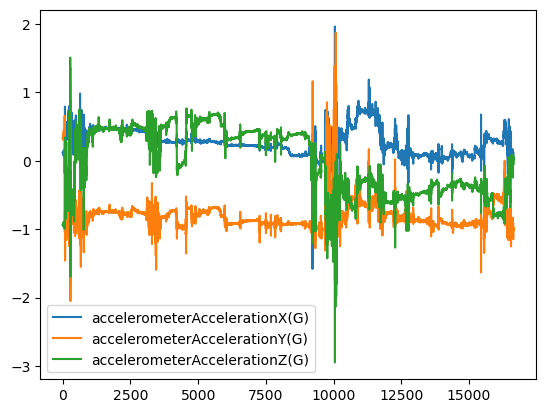

In [22]:
accel_cols = ['accelerometerAccelerationX(G)', 'accelerometerAccelerationY(G)', 'accelerometerAccelerationZ(G)']
time_col = 'loggingTime(txt)'

day[accel_cols].plot()

<Axes: >

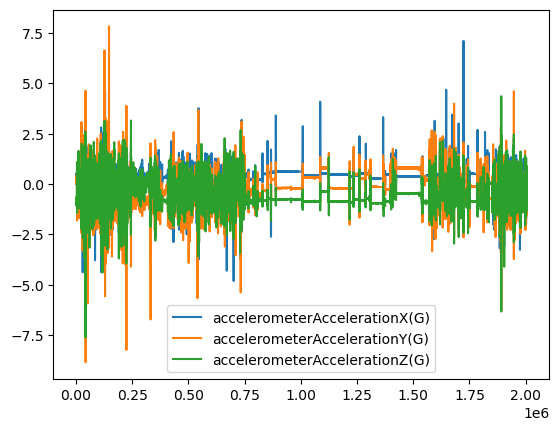

In [23]:
night[accel_cols].plot()

In [24]:
night_xyz = night[[time_col, *accel_cols]]
day_xyz = day[[time_col, *accel_cols]]

In [25]:
day_xyz.rename(columns = {
    'accelerometerAccelerationX(G)': 'x',
    'accelerometerAccelerationY(G)': 'y',
    'accelerometerAccelerationZ(G)': 'z'
}, inplace = True)

night_xyz.rename(columns = {
    'accelerometerAccelerationX(G)': 'x',
    'accelerometerAccelerationY(G)': 'y',
    'accelerometerAccelerationZ(G)': 'z'
}, inplace = True)

day_xyz['timestamp'] = pd.to_datetime(day_xyz[time_col]).astype(int) / 10 ** 9
night_xyz['timestamp'] = pd.to_datetime(night_xyz[time_col]).astype(int) / 10 ** 9

/var/folders/h4/pg7xmblx74zbp2yhls4bc_mh0000gn/T/ipykernel_91386/247370502.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_xyz.rename(columns = {
/var/folders/h4/pg7xmblx74zbp2yhls4bc_mh0000gn/T/ipykernel_91386/247370502.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  night_xyz.rename(columns = {
/var/folders/h4/pg7xmblx74zbp2yhls4bc_mh0000gn/T/ipykernel_91386/247370502.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/us

In [26]:
day_xyz.head()

,loggingTime(txt),x,y,z,timestamp
0,2024-12-11T13:26:11.807-06:00,0.119873,0.337906,-0.939240,1.733945e+09
1,2024-12-11T13:26:11.837-06:00,0.120834,0.334152,-0.932907,1.733945e+09
2,2024-12-11T13:26:11.871-06:00,0.121201,0.341263,-0.933777,1.733945e+09
3,2024-12-11T13:26:11.902-06:00,0.114990,0.327347,-0.940186,1.733945e+09
4,2024-12-11T13:26:11.932-06:00,0.119659,0.321487,-0.934875,1.733945e+09


In [27]:
day_xyz.drop(columns=[time_col], inplace=True)

/var/folders/h4/pg7xmblx74zbp2yhls4bc_mh0000gn/T/ipykernel_91386/222234887.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_xyz.drop(columns=[time_col], inplace=True)


In [30]:
day_xyz.to_csv(day_fn.replace('raw_', 'cleaned_'), index=False, columns=['timestamp', 'x', 'y', 'z'])

In [32]:
# night_xyz.drop(columns=[time_col], inplace=True)
night_xyz.to_csv(night_fn.replace('raw_', 'cleaned_'), index=False, columns=['timestamp', 'x', 'y', 'z'])

# Now load using Pisces

In [1]:
from pisces.data_sets import DataSetObject

sets = DataSetObject.find_data_sets('../../data/')

In [2]:
sets.keys()

dict_keys(['hybrid_motion', 'hf_disordered', 'eric_exports', 'walch_et_al'])

In [3]:
e = sets['eric_exports']

In [4]:
e.parse_data_sets()

In [5]:
e.ids

['2024_12_1011', '2024_12_11_wake']

In [40]:
night = e.get_feature_data('accelerometer', '2024_12_1011').to_numpy()
day = e.get_feature_data('accelerometer', '2024_12_11_wake').to_numpy()

In [41]:
1/32

0.03125

In [42]:
np.diff(day[:, 0])

array([0.02999973, 0.03400016, 0.03100014, ..., 0.02400017, 0.02999997,
       0.02999997])

In [43]:
type(night)

numpy.ndarray

In [48]:
from pisces.utils import accelerometer_to_3d_specgram
from scipy.signal import resample

import numpy as np
# Resample the night data from 50 Hz to 32 Hz
# num_samples = int(night.shape[0] * (32 / 50))
DT = 1/32
night_start = night[0, 0]
night_end = night[-1, 0]
for i in range(night.shape[1]):
    night = np.interp(np.arange(night_start, night_end + DT, DT), night[:, 0], night)


night_spec, night_times, night_freqs = accelerometer_to_3d_specgram(night)
day_spec, day_times, day_freqs  = accelerometer_to_3d_specgram(day)

ValueError: object too deep for desired array

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def overlay_channels_fixed(spectrogram_tensor, mintile=5, maxtile=95, ax=None, clip: bool = False):
    """
    Overlay spectrogram channels as an RGB image by stacking the three axes (x, y, z).
    
    Parameters:
        spectrogram_tensor (numpy.ndarray): Spectrogram tensor of shape (time_bins, freq_bins, 3).
    """
    # Normalize each channel to [0, 1] for proper RGB visualization
    norm_spec = np.zeros_like(np.squeeze(spectrogram_tensor))
    if clip:
        for i in range(3):
            channel = spectrogram_tensor[:, :, i]
            p5, p95 = np.percentile(channel, [mintile, maxtile])  # Robust range
            norm_spec[:, :, i] = np.clip((channel - p5) / (p95 - p5 + 1e-8), 0, 1)  # Avoid dividing by zero
    else:
        spec_max = np.max(spectrogram_tensor)
        spec_min = np.min(spectrogram_tensor)
        norm_spec = (spectrogram_tensor - spec_min) / (spec_max - spec_min)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    # Display the combined RGB image

    ax.imshow(norm_spec, aspect='auto', origin='lower', interpolation='none')
    # add_rgb_legend(plt.gca())
    # plt.colorbar(label='Intensity')
    ax.set_xlabel('Time Bins')
    ax.set_ylabel('Frequency Bins')
    ax.set_title('Overlayed Spectrogram Channels as RGB')



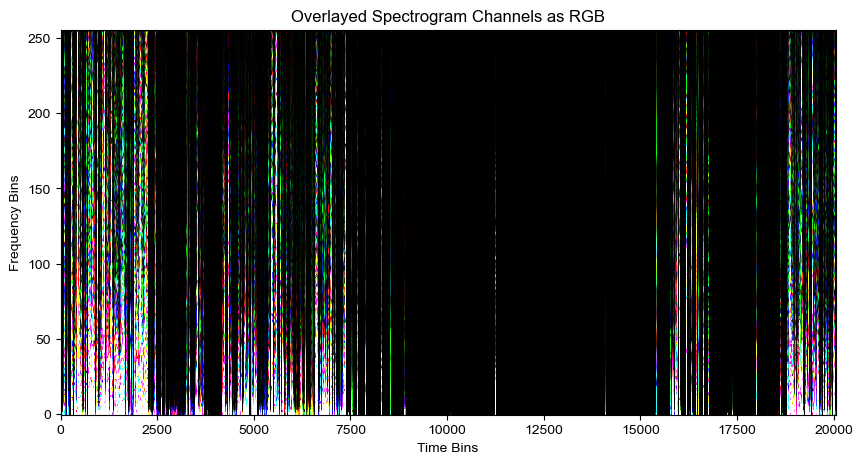

In [47]:
overlay_channels_fixed(night_spec.swapaxes(0, 1), mintile=10,  clip=True)

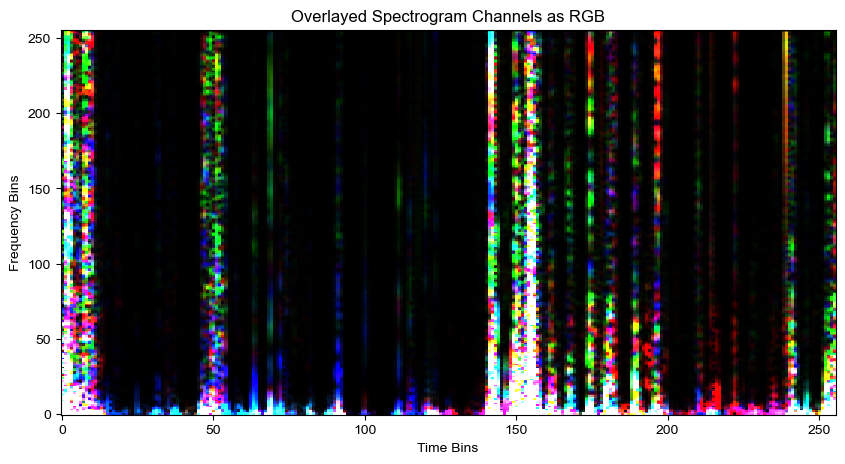

In [46]:
overlay_channels_fixed(day_spec.swapaxes(0, 1), mintile=1,  clip=True)

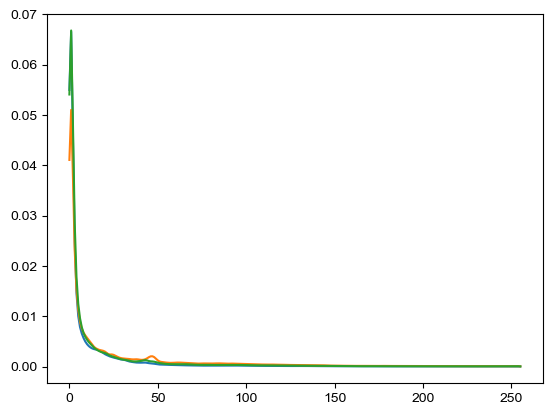

In [28]:
for i in range(3):
    plt.plot(night_spec[:, :, i].mean(axis=0))

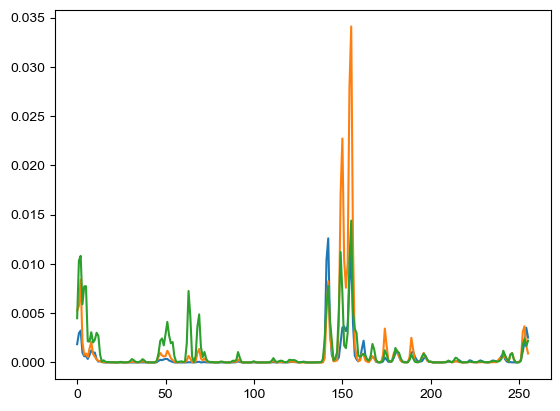

In [27]:
for i in range(3):
    plt.plot(day_spec[:, :, i].mean(axis=1))